<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/mariano/mariano_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 2: Análisis exploratorio y curación de datos

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Objetivo**: responder al menos tres de las preguntas planteadas por el grupo en el trabajo práctico 1.

Se espera un manejo más avanzado del set de datos, en donde el grupo de trabajo relacione las distintas columnas del dataset (variables) para responder preguntas con una complejidad mayor que la de realizar una mera descripción.

Cada respuesta a cada pregunta debe contener los siguientes apartados para considerarse completa:

1. **Planteo de la pregunta.** Se deben incluir las implicancias o las consecuencias de poder responderla. Por ejemplo, si la pregunta es ¿cuándo presentan mayor cantidad de huevos las hembras de cada una de las especies? Tiene implicancia directa en el manejo pesquero de la especie. Explicitar.

2. **Desarrollo del paso a paso que se hizo para responder a la pregunta.** Por ejemplo, ¿cómo se consideraron los datos faltantes? ¿qué individuos se consideraron y cuáles no?

3. Al menos **un gráfico por pregunta respondida**, así como su interpretación.

In [1]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

sns.set_context('talk')
pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 400

In [3]:
# Importo dataset original
url_original_data = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
data_original = pd.read_csv(url_original_data, sep=';', engine='python', encoding='latin1')

In [7]:
# Cargo el CSV local guardado en Drive con datos jul97
url_jul97 = 'https://raw.github.com/Mariano-ds/centollas2026/main/datos/jul97.csv'
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

In [8]:
# Estandarizacion previa - nombres de columnas
data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

# Concatenar los DataFrames
# axis=0 une por filas alineando automáticamente por nombre de columna
# ignore_index=True reindexa las filas de 0 a N para evitar índices repetidos
df_full = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)

# Confirmación de la estructura unificada
print(f"Filas totales: {df_full.shape[0]} | Columnas totales: {df_full.shape[1]}")
df_raw = df_full.copy()
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


### Informacion acerca de las variables

Datos genrales de las campañas:

- enero_96 > Muestreo a bordo de Wapisa, 26/01/96; WAPJAN96
- abril_96 > Muestreo a bordo de Catamarca 2/4/96
- julio_96 > Muestreo a bordo de Wapisa y Catamarca, 24 y 25.07.96; LANJUL96.WQ1
- octubre_96 > Muestreo a bordo de Catamarca, 2 y 3.10.96; CATOCT96.WQ1
- octubre_97 > Muestreo a bordo de la Catamarca el 6 y 7 de octubre de 1997
- octubre_98 > Muestreo a bordo de la Catamarca el 13 de octubre de 1998

Datos adicionales:

- julio_97

La codificación de las variables categóricas se reconstruyó a partir del protocolo de muestreo
(Lovrich, *Lithodes - Muestreo*) que documenta el criterio de toma de datos en el campo.

| Variable | Descripción | Códigos / Unidades |
|---|---|---|
| `fecha` | Temporada de muestreo | ene_96, abril_96, jul_96, oct_96, jul_97, oct_97, oct_98 |
| `rk` | Número de registro/individuo dentro de la temporada | entero |
| `tipo` | Tipo de captura y cantidad de trampas (o desembarque) del punto de muestreo | texto, p.ej. "Captura total de 3 trampas" |
| `localizacion` | Punto de referencia geográfico del muestreo | texto libre |
| `latitud`, `longitud` | Coordenadas del punto de muestreo | grados decimales |
| `profundidad` | Profundidad del punto de muestreo | metros |
| `especie` | Especie del individuo | 1 = centolla (*Lithodes santolla*), 2 = centollón (*Paralomis granulosa*) |
| `sexo` | Sexo del individuo | 1 = macho, 2 = hembra* |
| `estado_caparazon` | Estado del caparazón / epibiosis | 1 postmuda, 2 duro sin epibiontes, 3 duro con epibiontes (Spirorbis), 4 duro con epibiontes (Balanus), 5 duro con 2º caparazón visible, 6 exuvia, 30 entre estado 2 y 3 |
| `cirripedio` | Presencia/nivel de cirripedios (parásito *Briarosaccus*) | 1–3 (nivel), sufijo "p" en algunos registros |
| `largo_caparazon` | Largo del caparazón (LC) | mm |
| `ancho_caparazon` | Ancho del caparazón | mm |
| `largo_quela` | Largo de la pinza derecha | mm |
| `ancho_quela` | Ancho de la pinza derecha | mm |
| `huevos` | Estado de desarrollo de los huevos (solo hembras) | 0 sin huevos, 1 huevos sin ojos, 2 huevos sin ojos con mancha blanca, 3 huevos con ojos, 4 eclosionando, 5 cápsulas vacías (postovígera), 6 embriogénesis heterogénea, 7 trazas |
| `parasito` | Presencia de parásito *Pseudione* | 2 isopodo presente, 20 isopodo cicatriz, 3 rizocefalo presente, 30 rizocefalo cicatriz |
| `observaciones` | Notas de campo | texto libre |


In [9]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             13114 non-null  str    
 1   rk                13114 non-null  int64  
 2   tipo              13114 non-null  str    
 3   localizacion      9021 non-null   str    
 4   latitud           7970 non-null   float64
 5   longitud          7970 non-null   float64
 6   profundidad       9765 non-null   float64
 7   especie           13114 non-null  int64  
 8   sexo              13114 non-null  int64  
 9   estado_caparazon  13106 non-null  float64
 10  cirripedio        1840 non-null   object 
 11  largo_caparazon   13087 non-null  float64
 12  ancho_caparazon   183 non-null    float64
 13  largo_quela       196 non-null    float64
 14  ancho_quela       198 non-null    float64
 15  huevos            3771 non-null   object 
 16  parasito          296 non-null    object 
 17  obse

<Axes: >

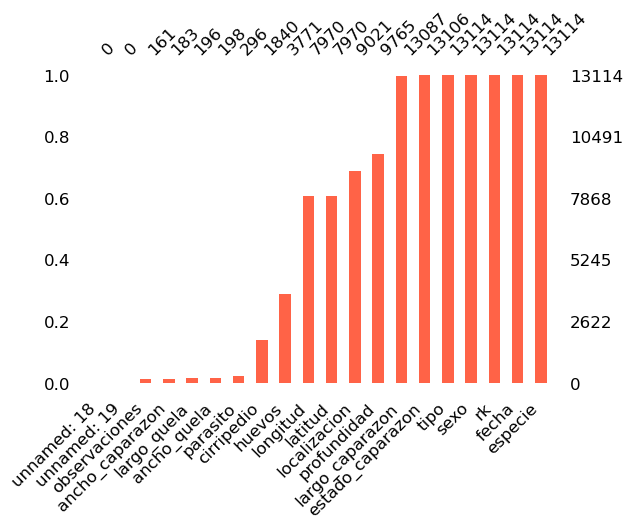

In [10]:
# Visualizacion de valores nulos
msno.bar(df_raw,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

In [11]:
# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

unnamed: 18         100.00
unnamed: 19         100.00
observaciones        98.77
ancho_caparazon      98.60
largo_quela          98.51
ancho_quela          98.49
parasito             97.74
cirripedio           85.97
huevos               71.24
latitud              39.23
longitud             39.23
localizacion         31.21
profundidad          25.54
largo_caparazon       0.21
estado_caparazon      0.06
dtype: float64


## 1. Limpieza inicial del dataset  

Se eliminan las columnas `unnamed: 18` y `unnamed: 19` ya que no aportan información.

In [12]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
df_raw.drop(columns=['unnamed: 18', 'unnamed: 19'], inplace=True)
df_raw.dropna(subset=['largo_caparazon'],how='any',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 13,087 | Columnas: 18


Las columnas más relevantes para nuestro estudio serán las asociadas a la cantidad de cangrejos en la muestra, su ubicación temporal y espacial, seguido de las características físicas de los mismos.

Puesto que estamos interesados en estudiar la distribución espacial, se eliminan las entradas con localizacion, latitud y altitud simultaneamente nulas. Estos casos no permiten inferir de ninguna manera robusta dónde se realizó la pesca, por lo que se descartan del estudio.



In [13]:
# Elimina la fila SOLO si latitud, longitud y localizacion son NaN simultáneamente
df_raw.dropna(subset=['latitud', 'longitud', 'localizacion'],how='all',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 9,105 | Columnas: 18


Debido al alto porcentaje de entradas nulas, se descartan las columnas `ancho_caparazon`, `largo_quela` y `ancho_quela`, pues no permiten sacar conclusiones sobre la muestra.


In [14]:
df_raw.drop(columns=['ancho_caparazon', 'largo_quela', 'ancho_quela'], inplace=True)

Se procede a limpiar la columna de `tipo` de captura, extrayendo cuando sea posible la cantidad de trampas empleadas durante cada campaña. Esto permite calcular el esfuerzo de captura posteriormente:

In [15]:
df_raw['tipo'].value_counts()

tipo
Captura total de 4 trampas       895
Captura total de 3 trampas       893
Captura total de 10 trampas      813
Captura total de 2 trampas       709
Captura total de 1 trampa        618
Captura total de 5 trampas       589
Captura total de 2.5 trampas     588
Captura total de 0.75 trampas    461
Captura total de 0.8 trampas     409
Captura total 2 trampas          369
Captura total de 1.8 trampas     350
Captura total de 1.5 trampas     341
Captura total 6 trampas          185
Captura total de 4.9 trampas     184
Captura total de 7 trampas       170
Captura total de 1.75 trampas    165
Captura total de 1.33 trampas    158
Captura total de 6 trampas       155
Captura total 9 trampas          149
Captura total de 4.75 trampas    140
Captura total 8 trampas          118
Captura total de 8 trampas       113
Captura total trampas wp 149     110
Captura total de 0.5 trampas      84
Captura total de 2.75 trampas     79
Captura por la Wapisa             75
Captura total 10 trampas         

In [16]:
def extraer_num_trampas(tipo_str):
    """
    Extrae el número de trampas vinculando explícitamente la cantidad
    con los términos 'trampa' o 'linea'.
    """
    if pd.isna(tipo_str):
        return np.nan

    texto = str(tipo_str).lower()

    # 1. Patrón con número ANTES del término (ej: "10 trampas", "captura de 2 líneas")
    match_antes = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)

    # 2. Patrón con número DESPUÉS del término (ej: "trampas: 10", "línea 2")
    match_despues = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)

    if match_antes:
        numero = float(match_antes.group(1))
        unidad = match_antes.group(2)
    elif match_despues:
        unidad = match_despues.group(1)
        numero = float(match_despues.group(2))
    else:
        # Casos como "Captura total trampas wp 149" (sin cantidad especificada) o muestreos
        return np.nan

    # 3. Conversión de unidades (1 línea = 10 trampas)
    if 'linea' in unidad or 'línea' in unidad:
        return numero * 10.0
    return numero

In [17]:
# Aplicar función
df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)

n_total = len(df_raw)
n_validos = df_raw['num_trampas'].notna().sum()
n_excluidos = n_total - n_validos

print("=="*50)
print(f" Registros con esfuerzo de pesca identificable: {n_validos} ({n_validos/n_total*100:.1f}%)")
print(f" Registros excluidos del cálculo de IAR (índice de abundancia relativa): {n_excluidos} ({n_excluidos/n_total*100:.1f}%)")
print("=="*50)

print("\nCategorías excluidas (sin equivalente en trampas):")
print(df_raw[df_raw['num_trampas'].isna()]['tipo'].value_counts())

 Registros con esfuerzo de pesca identificable: 8865 (97.4%)
 Registros excluidos del cálculo de IAR (índice de abundancia relativa): 240 (2.6%)

Categorías excluidas (sin equivalente en trampas):
tipo
Captura total trampas wp 149    110
Captura por la Wapisa            75
Muestreo de cubierta 3           55
Name: count, dtype: int64


A continuación se calcula el Índice de Abundancia Relativa. El cálculo se hace sobre el dataframe completo, creando una máscara sobre las entradas válidas para este estudio. Se desestiman del cálculo las entradas cuyo tipo de captura sea Desembarque, Muestreo de cubierta y similares. En estos casos, su IAR será NaN.

In [18]:
df_trampas = df_raw[df_raw['num_trampas'].notna()].copy()
print(f"Registros originales: {len(df_raw)}")
print(f"Registros descartados (desembarque, muestreo de cubierta, etc.): {len(df_raw) - len(df_trampas)}")

# 1. Definir la máscara para eventos con número de trampas válido
mask_trampas = df_raw['num_trampas'].notna() & (df_raw['num_trampas'] > 0)

# 2. Inicializar la columna IAR con NaN
df_raw['IAR'] = np.nan

# 3. Contar capturas (número de filas) por cada evento (localizacion, fecha, tipo)
capturas_por_evento = df_raw[mask_trampas].groupby(['localizacion', 'fecha', 'tipo'])['num_trampas'].transform('count')

# 4. Calcular el IAR vectorizado (Capturas / Trampas) para los registros válidos
df_raw.loc[mask_trampas, 'IAR'] = capturas_por_evento / df_raw.loc[mask_trampas, 'num_trampas']

# Presentacion de algunos resultados generales
print(f"\nIAR calculado")
print(f"   Máximo   IAR: {df_raw['IAR'].max():.4f} ({df_raw['IAR'].idxmax()})")
print(f"   Mínimo   IAR: {df_raw['IAR'].min():.4f} ({df_raw['IAR'].idxmin()})")
print(f"   Promedio IAR: {df_raw['IAR'].mean():.4f}")

Registros originales: 9105
Registros descartados (desembarque, muestreo de cubierta, etc.): 240

IAR calculado
   Máximo   IAR: 282.5000 (3866)
   Mínimo   IAR: 0.0600 (3475)
   Promedio IAR: 76.8777


El dataframe de trabajo es el resultado de concatenar dos registros diferentes: al conjunto de datos originales se suma la campaña de jul97 provista posteriormente por nuestra mentora. Para estudiar la evolución temporal de los registros, es necesario ordenar las entradas correctamente.

A continuación se ordena el dataframe de manera que las campañas se sucedan coherentemente en el tiempo.

In [19]:
# Definicion de la prioridad cronologica de las campañas
orden_campanas = {
    'ene_96': 1,
    'abril_96': 2,
    'jul_96': 3,
    'oct_96': 4,
    'jul_97': 5,
    'oct_97': 6,
    'oct_98': 7
}

# Se ordena con 'key' y se reinicia el índice
df_raw = df_raw.sort_values(by='fecha', key=lambda x: x.map(orden_campanas)).reset_index(drop=True)

El porcentaje de nulos del dataframe de trabajo actualmente es el siguiente:

In [20]:
print("="*50)
print("Resumen de limpieza inicial - Estado actual del df")
print("="*50)

print(f"\nFilas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}\n")

# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Resumen de limpieza inicial - Estado actual del df

Filas: 9,105 | Columnas: 17

observaciones       98.58
parasito            97.25
cirripedio          86.23
huevos              62.47
latitud             12.73
longitud            12.73
IAR                  2.64
num_trampas          2.64
profundidad          1.50
localizacion         1.21
estado_caparazon     0.02
dtype: float64


### 1.1 Composición del dataset limpio

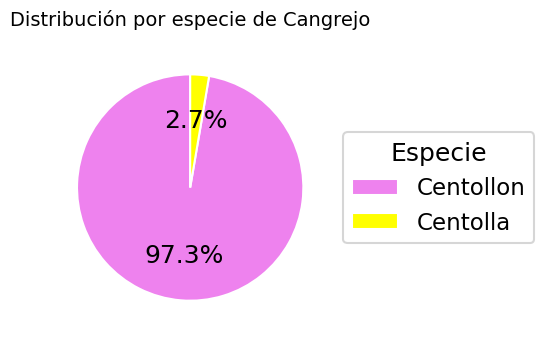

In [21]:
# @title
# Diccionario de mapeo
mapa_especies = {
    1: 'Centolla',
    2: 'Centollon',
    '1': 'Centolla',
    '2': 'Centollon',
}

# Conteo de valores
conteo = df_raw['especie'].value_counts()

# Mapear los índices traducidos para la leyenda
etiquetas = [mapa_especies.get(x, str(x)) for x in conteo.index]

plt.figure(figsize=(5, 4))

# Generar el gráfico asignando los elementos a variables para la leyenda
wedges, texts, autotexts = plt.pie(
    conteo,
    autopct='%1.1f%%',
    colors=sns.color_palette(['violet', 'yellow']),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)

# Agregar la leyenda con las nuevas etiquetas
plt.legend(
    wedges,
    etiquetas,
    title='Especie',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
)

plt.title('Distribución por especie de Cangrejo', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

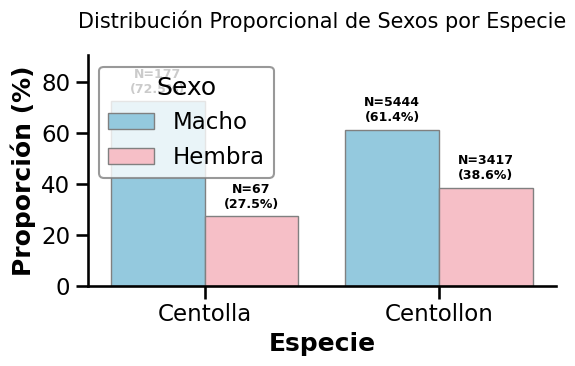

In [22]:
# @title
# Mapeo de codificación
mapa_sexo = {
    1: 'Macho',
    2: 'Hembra'
}

# Aplicar mapeo a una copia del DataFrame
df_plot = df_raw.copy()
df_plot['especie_nom'] = df_plot['especie'].map(mapa_especies)
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo)

# Calcular Conteos (N) y Porcentajes dentro de cada especie
ct_counts = pd.crosstab(df_plot['especie_nom'], df_plot['sexo_nom'])
ct_pct = (
    pd.crosstab(
        df_plot['especie_nom'], df_plot['sexo_nom'], normalize='index'
    )
    * 100
)

# Convertir a formato largo para Seaborn
df_counts = ct_counts.reset_index().melt(
    id_vars='especie_nom', value_name='n_muestras'
)
df_pct = ct_pct.reset_index().melt(
    id_vars='especie_nom', value_name='porcentaje'
)
df_final = pd.merge(df_counts, df_pct, on=['especie_nom', 'sexo_nom'])

# Paleta exacta: Celeste para Macho, Rosa para Hembra
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}  # Skyblue y Lightpink

orden_especie = ['Centolla', 'Centollon']
orden_sexo = ['Macho', 'Hembra']

# Crear el gráfico
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_final,
    x='especie_nom',
    y='porcentaje',
    hue='sexo_nom',
    order=orden_especie,
    hue_order=orden_sexo,
    palette=paleta_sexo,
    edgecolor='gray',
    linewidth=1,
)

# Agregar el número de muestras (N) sobre cada barra
# (se usa un orden explícito para emparejar cada container con su categoría real,
# en vez de container.get_label(), que no devuelve 'Macho'/'Hembra')
for sexo_cat, container in zip(orden_sexo, ax.containers):
    sub_df = (
        df_final[df_final['sexo_nom'] == sexo_cat]
        .set_index('especie_nom')
        .reindex(orden_especie)
    )
    etiquetas = [
        f"N={int(row['n_muestras'])}\n({row['porcentaje']:.1f}%)"
        for _, row in sub_df.iterrows()
    ]
    ax.bar_label(
        container, labels=etiquetas, padding=4, fontsize=9, fontweight='bold'
    )

# Estética y Caja de Leyenda
plt.title('Distribución Proporcional de Sexos por Especie', fontsize=15, pad=20)
plt.xlabel('Especie', fontweight='bold')
plt.ylabel('Proporción (%)', fontweight='bold')
plt.ylim(
    0, df_final['porcentaje'].max() * 1.25
)  # Margen superior para los textos

# Caja de leyenda
plt.legend(
    title='Sexo',
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='gray',
)

sns.despine()
plt.tight_layout()
plt.show()

## 2. Corrección de columnas numéricas y categóricas

Estudiemos las variables que quedan con dtype str:  cirripedio, huevos y parasito.

Según la descripcion de los features provistos junto al dataset, hay una serie de columnas cuyos tipos son incorrectos. `estado_caparazon` es flotante en lugar de entero, y las columnas `cirripedio`, `huevos` y `parasito` figuran como str, en lugar de ser variables enteras.

In [23]:
# Copia posterior a la limpieza inicial
df_clean = df_raw.copy()

### 2.1 `estado_caparazon`

La codificación de esta variable es:

- 1 postmuda,
- 2 duro sin epibiontes,
- 3 duro con epibiontes (Spirorbis),
- 4 duro con epibiontes (Balanus),
- 5 duro con 2º caparazón visible,
- 6 exuvia,
- 30 entre estado 2 y 3.

In [24]:
df_clean['estado_caparazon'].value_counts()

estado_caparazon
3.0     7602
4.0     1207
30.0     153
2.0      130
1.0        7
6.0        2
5.0        2
Name: count, dtype: int64

Los registros no tienen errores en esta variable. No se efectuaron cambios.

### 2.2 `cirripedio`

La codificación de esta variable es:

1–3 (tamaño), sufijo "p" en algunos registros indica presencia en patas. Caso contrario, presencia en caparazón.

NOTA: Los valores decimales reportados significan presencia de cirripedios de diversos tamaños. Por ejemplo, 1.2 se interpreta como que había tamaño 1 y tamaño 2 en caparazón.

In [25]:
df_clean['cirripedio'].value_counts()

cirripedio
2       797
2.0     370
1        45
3        18
2.3      11
3.0       4
1.0       4
2p        2
1p        1
1.2       1
1.23      1
Name: count, dtype: int64

Debido a que el sufijo 'p' se presentó en únicamente 3 de las >1250 observaciones no nulas, se descartó la creación de una variable indicadora binaria para evitar problemas de varianza nula y desbalance extremo en los pliegues de validación cruzada. Para preservar la integridad del dataset, la variable fue consolidada en su escala numérica base ( 1,2,3 ) removiendo el sufijo marginal. Se conserva solo la caracterizacion de la presencia de cirripedios y no se indica en qué parte del individuo se encuentra, pues para nuestro posterior análisis no resulta relevante tal nivel de detalle.

Se corrije así el tipo de datos str -> float.

In [26]:
# Diccionario de correcciones:
correcciones_cirripedio = {
    '2p': '2',
    '1p': '1'
}

# Aplicar el reemplazo
df_clean['cirripedio'] = df_clean['cirripedio'].replace(correcciones_cirripedio)
df_clean['cirripedio'] = df_clean['cirripedio'].apply(lambda x: float(x))
df_clean['cirripedio'].value_counts()

cirripedio
2.00    1169
1.00      50
3.00      22
2.30      11
1.20       1
1.23       1
Name: count, dtype: int64

### 2.3 `parasitos`

La codificación de esta variable es:

- 2 isopodo presente,
- 20 isopodo cicatriz,
- 3 rizocefalo presente,
- 30 rizocefalo cicatriz



In [27]:
df_clean['parasito'].value_counts()

parasito
20       169
2         34
3         18
20.0      16
30         9
2.0        2
3,20       1
30,20      1
Name: count, dtype: int64

In [28]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             9105 non-null   str    
 1   rk                9105 non-null   int64  
 2   tipo              9105 non-null   str    
 3   localizacion      8995 non-null   str    
 4   latitud           7946 non-null   float64
 5   longitud          7946 non-null   float64
 6   profundidad       8968 non-null   float64
 7   especie           9105 non-null   int64  
 8   sexo              9105 non-null   int64  
 9   estado_caparazon  9103 non-null   float64
 10  cirripedio        1254 non-null   float64
 11  largo_caparazon   9105 non-null   float64
 12  huevos            3417 non-null   object 
 13  parasito          250 non-null    object 
 14  observaciones     129 non-null    str    
 15  num_trampas       8865 non-null   float64
 16  IAR               8865 non-null   float64
dtypes: flo

Dado que las muestras con doble categoría representaban únicamente 2 de los 9105 registros totales conservados luego de la limpieza inicial, se descartó la implementación de un esquema multi-etiqueta para evitar problemas de varianza por categorías atípicas. En su lugar, se procedió a reasignar dichas entradas a su categoría principal.

Se reporta la presencia del parásito frente a la cicatriz en el primer caso; y se reporta la cicatriz de la clase minoritaria en el segundo caso.

In [29]:
# Diccionario de correcciones:
correccion_parasito = {
    '3,20': '3', # Priorizo el parasito presente
    '30,20': '30'
}

# Aplicar el reemplazo
df_clean['parasito'] = df_clean['parasito'].replace(correccion_parasito)
df_clean['parasito'] = df_clean['parasito'].apply(lambda x: float(x))
df_clean['parasito'].value_counts()

parasito
20.0    185
2.0      36
3.0      19
30.0     10
Name: count, dtype: int64

### 2.3 `huevos`

La codificación de esta variable es:

- 0 sin huevos,
- 1 huevos sin ojos,
- 2 huevos sin ojos con mancha blanca,
- 3 huevos con ojos,
- 30 comienzo del estadío 3*,
- 4 eclosionando,
- 40 comienzo del estadío 4*,
- 5 cápsulas vacías (postovígera),
- 6 embriogénesis heterogénea,
- 7 trazas.

Nota: (*) fue información provista por nuestra mentora, no declarada en la documentación original del dataset.

In [30]:
df_clean['huevos'].value_counts()

huevos
1          1099
0           727
30          455
3.0         231
1.0         217
5           201
6            95
7            89
3            75
0.0          72
5.0          64
4            29
30.0         18
7.0          18
40           10
4.0          10
conojos       2
6.0           2
7 en 1        1
po            1
2.0           1
Name: count, dtype: int64

In [31]:
# Muestra el registro que tiene huevos = po
df_clean[df_clean['huevos'] == 'po']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
1021,abril_96,163,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,2.0,80.7,po,NaN,NaN,2.0,82.0


Las correcciones numéricas sobre los valores observados consisten en unificar tipos de datos, pasando enteros a reales.

Para hacer las correcciones de texto, se estudian en detalle estos casos.



In [32]:
# Estudio de registros particulares huevos = conojos
df_clean[df_clean['huevos'] == 'conojos']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
919,abril_96,73,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,73.2,conojos,NaN,NaN,2.0,82.0
950,abril_96,106,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,71.8,conojos,NaN,NaN,2.0,82.0


In [33]:
# Estudio de registros particulares huevos = 7 en 1
df_clean[df_clean['huevos'] == '7 en 1']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
1012,abril_96,11,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,92.8,7 en 1,NaN,NaN,2.0,82.0


In [34]:
# Estudio de registro particular huevos = po
df_clean[df_clean['huevos'] == 'po']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
1021,abril_96,163,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,2.0,80.7,po,NaN,NaN,2.0,82.0


Se observa que todos los registros atípicos corresponden a la misma campaña y al mismo punto de pesca. Es posible que haya habido desinformación de la codificación de esta variable.

Las correcciones realizadas son las siguientes:

- Los registros cuyo valor es `conojos` se rectifican a 3, interpretando su texto literalmente como "con ojos".

- Los registros cuyo valor es `7 en 1` se rectifican a 1, interpretando su texto una observación sobre la cantidad de huevos sin ojos realizada fuera de su columna homónima.

- Los registros cuyo valor es `po` se descartan por falta de información.

In [35]:
# Registros de hembras cerca de Haskesheska en abril del 96
df_clean[(df_clean['localizacion'] == 'cerca de Haskesheska') & (df_clean['fecha'] == 'abril_96') & (df_clean['sexo'] == 2)]

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
898,abril_96,62,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,76.6,1,NaN,NaN,2.0,82.0
907,abril_96,53,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,82.1,1,NaN,NaN,2.0,82.0
908,abril_96,52,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,78.1,1,NaN,NaN,2.0,82.0
914,abril_96,78,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,75.5,1,NaN,NaN,2.0,82.0
919,abril_96,73,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,73.2,conojos,NaN,NaN,2.0,82.0
921,abril_96,71,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,76.7,1,NaN,NaN,2.0,82.0
923,abril_96,69,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,73.5,1,NaN,NaN,2.0,82.0
936,abril_96,88,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,75.3,1,NaN,NaN,2.0,82.0
944,abril_96,112,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,79.6,1,NaN,NaN,2.0,82.0
950,abril_96,106,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,71.8,conojos,NaN,NaN,2.0,82.0


Se realizan las correcciones mencionadas antes

In [36]:
# Descarte de huevos = po
df_clean = df_clean[df_clean['huevos'] != 'po']

# Diccionario de correcciones:
correccion_huevos = {
    # Corrección de texto
    'conojos': '3',
    '7 en 1': '1'
}

# Aplicar el reemplazo
df_clean['huevos'] = df_clean['huevos'].replace(correccion_huevos)
df_clean['huevos'] = df_clean['huevos'].apply(lambda x: float(x))
df_clean['huevos'].value_counts()

huevos
1.0     1317
0.0      799
30.0     473
3.0      308
5.0      265
7.0      107
6.0       97
4.0       39
40.0      10
2.0        1
Name: count, dtype: int64

## 3. Segmentación del estudio

En 1.1 se observa que las centollas representan menos del 3% de registros totales. Veamos cómo esta especie fue capturada a lo largo de las distintas temporadas y qué porcentaje de sus registros corresponde a hembras.

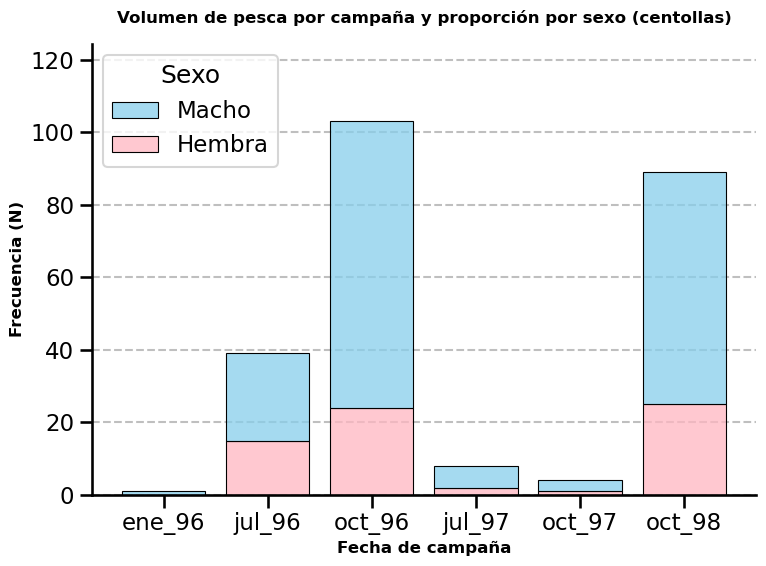

In [37]:
# @title

# Copia de trabajo, enfoque encentollas
df_plot = df_clean[df_clean['especie'] == 1].copy()

# 1. Mapear la columna sexo (1: Macho, 2: Hembra)
mapa_sexo = {1: 'Macho', 2: 'Hembra'}
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo).fillna(df_plot['sexo'])

# 3. Mapeo de colores específicos: Celeste (#87CEEB) para Machos, Rosa (#FFB6C1) para Hembras
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}

plt.figure(figsize=(8, 6))

# 4. Gráfico de barras apiladas mediante histplot
ax = sns.histplot(
    data=df_plot,
    x='fecha',
    hue='sexo_nom',
    hue_order=['Macho', 'Hembra'],
    multiple='stack',
    palette=paleta_sexo,
    shrink=0.8,
    edgecolor='black',
    linewidth=0.8
)

# 6. Ajuste de escala vertical y estética general
plt.ylim(0, ax.get_ylim()[1] * 1.15)
plt.title('Volumen de pesca por campaña y proporción por sexo (centollas)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Fecha de campaña', fontweight='bold', fontsize=12)
plt.ylabel('Frecuencia (N)', fontweight='bold', fontsize=12)

# Ajustar etiquetas de la leyenda
sns.move_legend(ax, "upper left", title="Sexo", frameon=True)

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

Se observa que sólo las campañas de octubre del 96 y del 98 tuvieron una pesca de más de 80 centollas, y en ningún caso la cantidad de hembras superó los 30 individuos. Los registros disponibles permiten un estudio muy acotado de esta especie, por lo que se decide focalizar el resto del trabajo únicamente en los centollones.   

In [38]:
# Descarte de registros de centollas
df_segmented = df_clean[df_clean['especie'] != 1].copy()

# Tamaño del dataframe segmentado
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 17


Habiendo segmentado los registros, se agrega una nueva columna booleana indicando si el centollón registrado es sexualmente maduro o no. Para ello, se utiliza el siguiente criterio a partir de información provista por nuestra mentora:

Si el largo del caparazón de un macho es al menos 50,2 mm, este es sexualmente maduro. En el caso de las hembras, su largo debe ser al menos 60,6 mm.

La codificación será entonces:

- 0 sexualmente inmaduro,
- 1 sexualmente maduro

In [39]:
# Condiciones de madurez según sexo y talla (mm)
df_test = df_segmented.copy()
macho_maduro = (df_segmented['sexo'] == 1) & (df_segmented['largo_caparazon'] >= 50.2)
hembra_madura = (df_segmented['sexo'] == 2) & (df_segmented['largo_caparazon'] >= 60.6)

# Nueva columna con codificación 1 (Maduro) y 0 (Inmaduro)
df_segmented['madurez_sexual'] = np.where(macho_maduro | hembra_madura, 1, 0)

# Tamaño del dataframe
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 18


Este dataframe será el punto de partida para responder a las preguntas solicitadas en este entregable, tomando los subconjuntos pertinentes en cada caso.

## ACA COMIENZO LO MIO

In [40]:
## Calculemos el indice de abundancia relativa (IAR)

# Agrupar por localización, fecha Y tipo -> cada combinación es un evento de muestreo independiente
iar_data = []
for (loc, fecha, tipo), group in df_segmented.groupby(['localizacion', 'fecha', 'tipo']):
    num_capturas = len(group)
    num_trampas_evento = group['num_trampas'].iloc[0]
    
    iar = num_capturas / num_trampas_evento if num_trampas_evento > 0 else 0
    
    iar_data.append({
        'Localización': loc,
        'Fecha': fecha,
        'Tipo': tipo,
        'N_Capturas': num_capturas,
        'N_Trampas': num_trampas_evento,
        'IAR': iar
    })

df_iar = pd.DataFrame(iar_data)
print("\n📊 Registros de IAR (por evento):")
print(df_iar.to_string(index=False))

iar_por_loc = df_iar.groupby('Localización').agg(
    N_Capturas=('N_Capturas', 'sum'),
    N_Trampas=('N_Trampas', 'sum')
).reset_index()
iar_por_loc['IAR_Total'] = iar_por_loc['N_Capturas'] / iar_por_loc['N_Trampas']
iar_por_loc = iar_por_loc.sort_values('IAR_Total', ascending=False)
iar_por_loc = iar_por_loc.set_index('Localización')

print(f"\n IAR calculado")
print(f"   Máximo IAR: {iar_por_loc['IAR_Total'].max():.4f} ({iar_por_loc['IAR_Total'].idxmax()})")
print(f"   Mínimo IAR: {iar_por_loc['IAR_Total'].min():.4f} ({iar_por_loc['IAR_Total'].idxmin()})")
print(f"   Promedio IAR: {iar_por_loc['IAR_Total'].mean():.4f}")


📊 Registros de IAR (por evento):
                                    Localización    Fecha                          Tipo  N_Capturas  N_Trampas        IAR
                            frente bal. Ponsatti   ene_96    Captura total de 3 trampas         234       3.00  78.000000
                                   E I. Martillo   jul_96  Captura total de 0.8 trampas         183       0.80 228.750000
                                   E I. Martillo   jul_96     Captura total de 1 trampa         169       1.00 169.000000
                                   E I. Martillo   jul_96  Captura total de 1.5 trampas         187       1.50 124.666667
N Snipe al traves con la baliza p. de los indios   ene_96    Captura total de 4 trampas         191       4.00  47.750000
                 S islote Belgrano/punta navarro   ene_96    Captura total de 2 trampas         121       2.00  60.500000
                               SW Ilote Belgrano   ene_96    Captura total de 7 trampas         170       7.00  

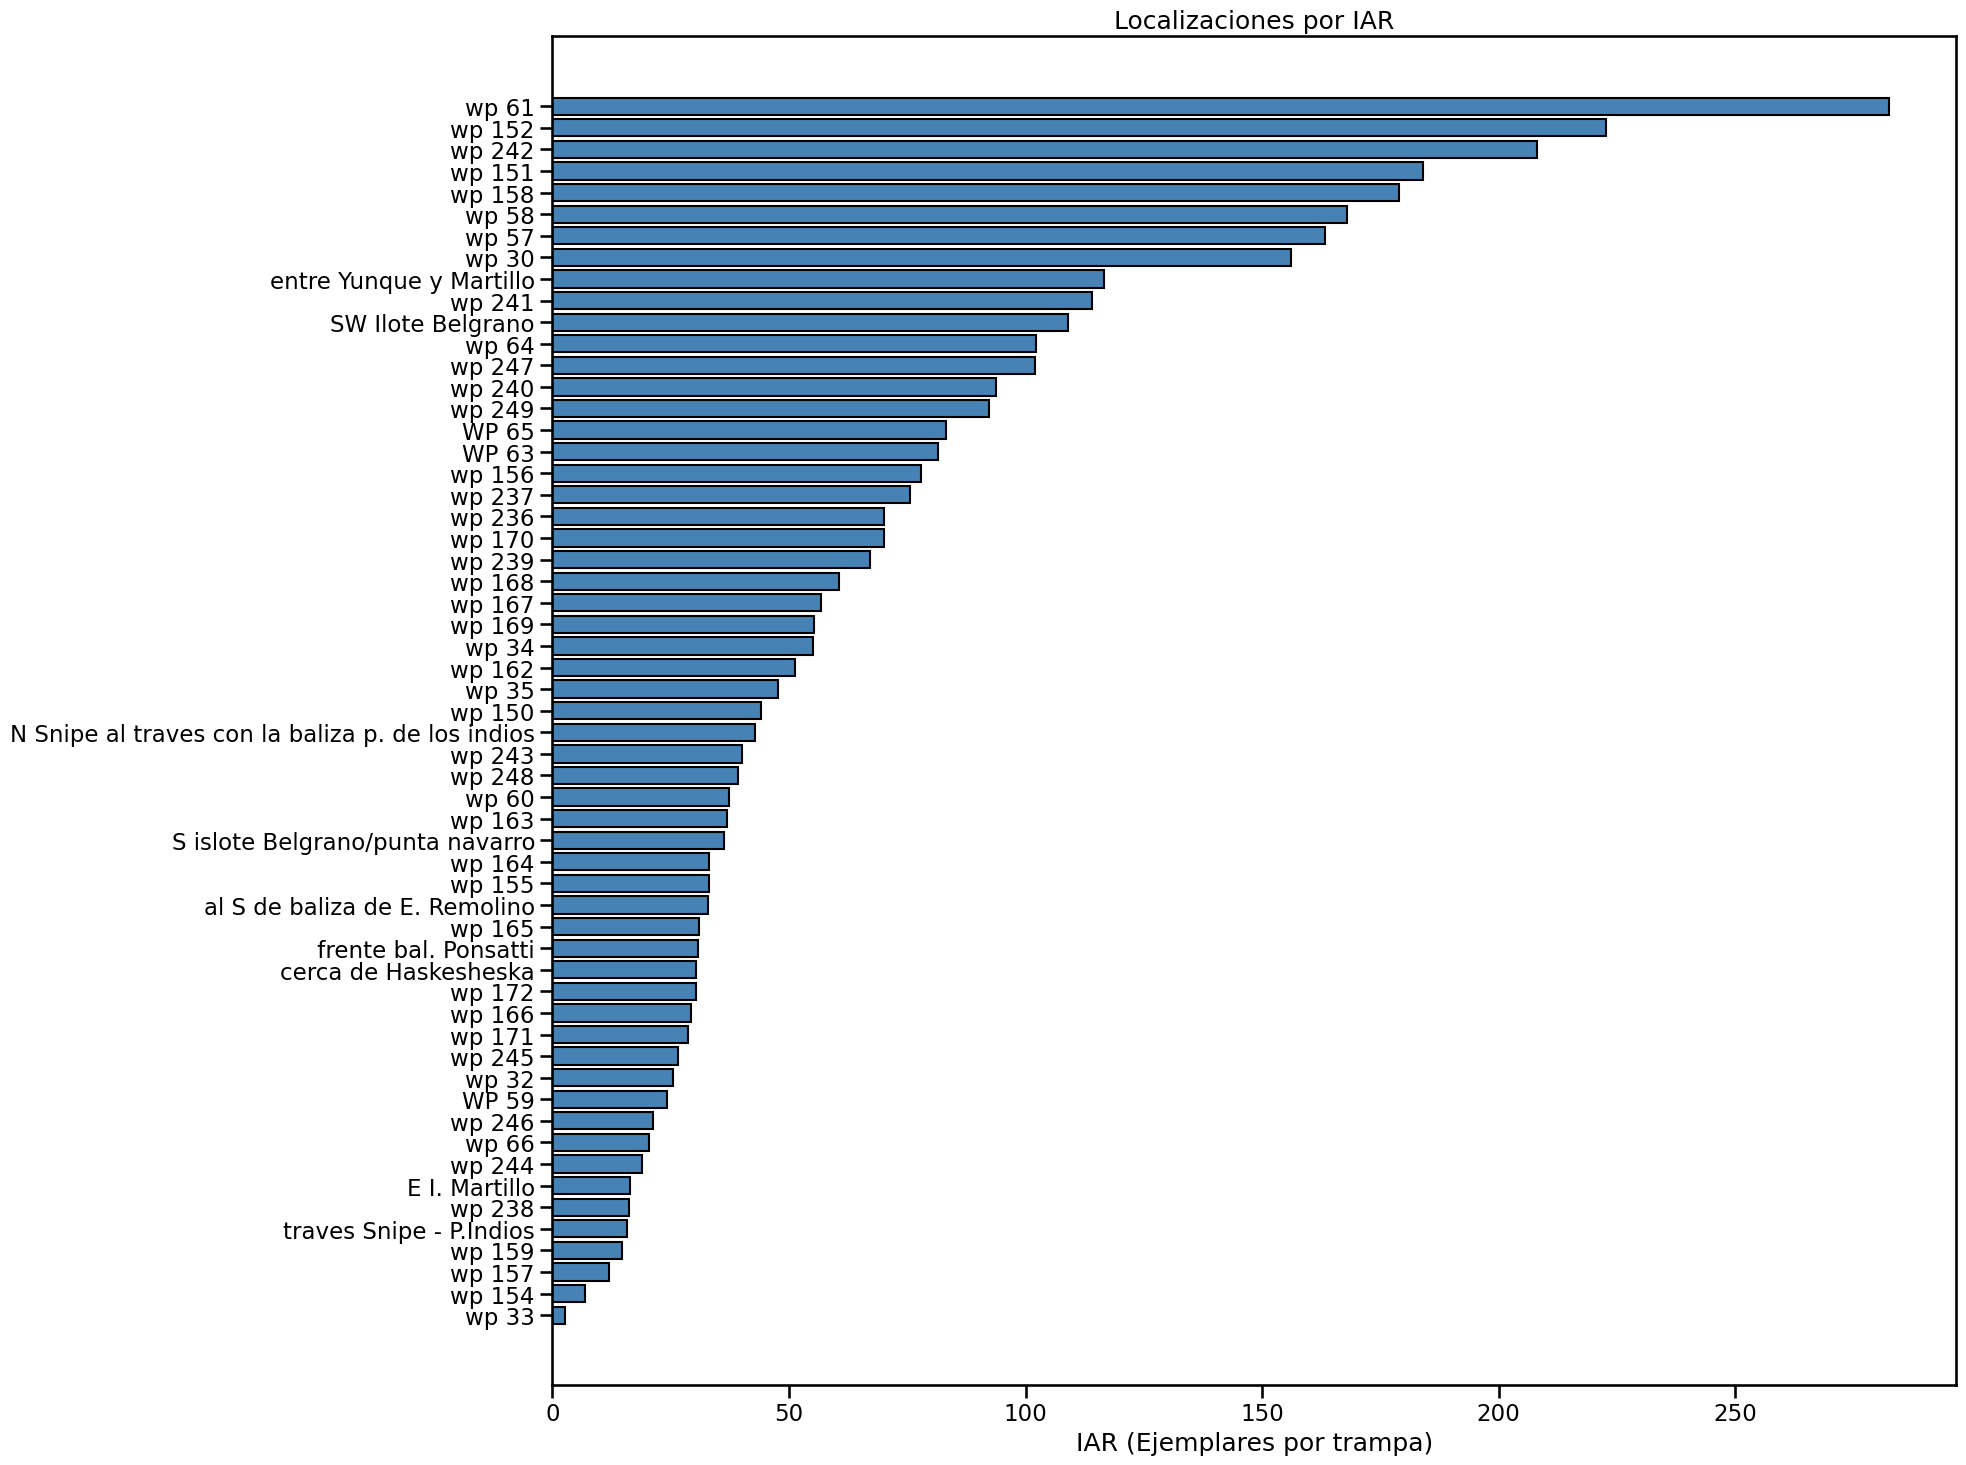

In [41]:
fig, ax = plt.subplots(figsize=(20,15))
ax.barh(iar_por_loc.sort_values('IAR_Total').index, iar_por_loc['IAR_Total'], color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('IAR (Ejemplares por trampa)')
ax.set_title('Localizaciones por IAR')
plt.tight_layout()
plt.show()

###  ¿Qué tienen en común las localizaciones de IAR alto?

Habiendo identificado las zonas con mayor abundancia relativa de machos, buscamos si estas localizaciones comparten alguna característica biológica. En particular, se compara la talla (largo de caparazón) y el estado de madurez sexual de los machos capturados en zonas de IAR alto contra el resto de las localizaciones. Si las zonas de IAR alto presentan ejemplares de menor talla (más jóvenes), podrían tratarse de zonas de crecimiento, para las cuales convendría evaluar restricciones de pesca.

In [42]:
# Localizaciones de IAR alto: por encima de la media + 1 desvío estándar
umbral_iar_alto = iar_por_loc['IAR_Total'].mean() + iar_por_loc['IAR_Total'].std()
locs_iar_alto = iar_por_loc[iar_por_loc['IAR_Total'] > umbral_iar_alto].index.tolist()

print(f"Umbral de IAR alto (media + 1σ): {umbral_iar_alto:.4f}")
print(f"Localizaciones de IAR alto ({len(locs_iar_alto)} de {len(iar_por_loc)}):")
for loc in locs_iar_alto:
    print(f"  - {loc} (IAR={iar_por_loc.loc[loc, 'IAR_Total']:.4f})")

Umbral de IAR alto (media + 1σ): 129.4707
Localizaciones de IAR alto (8 de 57):
  - wp 33 (IAR=282.5000)
  - wp 154 (IAR=222.6667)
  - wp 157 (IAR=208.0000)
  - wp 159 (IAR=184.0000)
  - traves Snipe - P.Indios (IAR=179.0000)
  - wp 238 (IAR=168.0000)
  - E I. Martillo (IAR=163.3333)
  - wp 244 (IAR=156.0000)


## ¿dónde hay más abundancia total del recurso (sin distinguir sexo), y ahí qué tamaño tienen los machos?

In [46]:

print(df_segmented['sexo'].value_counts())  

df_machos = df_segmented[df_segmented['sexo'] == 1].copy()  
print(f"df_machos recreado con {len(df_machos)} registros")

sexo
1    5444
2    3416
Name: count, dtype: int64
df_machos recreado con 5444 registros


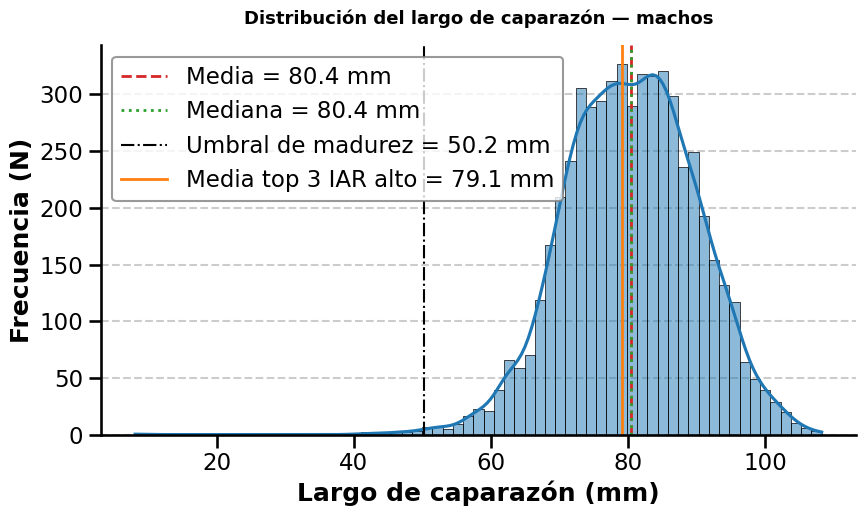

Media: 80.38 mm | Mediana: 80.40 mm | N: 5444
Top 3 localizaciones por IAR: ['wp 33', 'wp 154']
Media de largo de caparazón en esas localizaciones: 79.06 mm


In [47]:
media_largo = df_machos['largo_caparazon'].mean()
mediana_largo = df_machos['largo_caparazon'].median()

# Top 3 localizaciones de mayor IAR y talla media de los machos capturados en ellas
top3_iar_locs = iar_por_loc['IAR_Total'].nlargest(2).index.tolist()
media_largo_top3 = df_machos.loc[df_machos['localizacion'].isin(top3_iar_locs), 'largo_caparazon'].mean()

plt.figure(figsize=(9, 5.5))
ax = sns.histplot(df_machos['largo_caparazon'], kde=True, color='#1f77b4', edgecolor='black', linewidth=0.5)

ax.axvline(media_largo, color='#d62728', linestyle='--', linewidth=2, label=f'Media = {media_largo:.1f} mm')
ax.axvline(mediana_largo, color='#2ca02c', linestyle=':', linewidth=2, label=f'Mediana = {mediana_largo:.1f} mm')
ax.axvline(50.2, color='black', linestyle='-.', linewidth=1.5, label='Umbral de madurez = 50.2 mm')
ax.axvline(media_largo_top3, color='#ff7f0e', linestyle='-', linewidth=2, label=f'Media top 3 IAR alto = {media_largo_top3:.1f} mm')

ax.set_xlabel('Largo de caparazón (mm)', fontweight='bold')
ax.set_ylabel('Frecuencia (N)', fontweight='bold')
ax.set_title('Distribución del largo de caparazón — machos', fontsize=13, fontweight='bold', pad=15)
ax.legend(frameon=True, facecolor='white', edgecolor='gray')

sns.despine()
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
plt.tight_layout()
plt.show()

print(f"Media: {media_largo:.2f} mm | Mediana: {mediana_largo:.2f} mm | N: {df_machos['largo_caparazon'].count()}")
print(f"Top 3 localizaciones por IAR: {top3_iar_locs}")
print(f"Media de largo de caparazón en esas localizaciones: {media_largo_top3:.2f} mm")

Localizaciones ordenadas por menor talla media de machos:
                                                  talla_media  n_machos  IAR_Total
localizacion                                                                      
wp 32                                                  73.490       161    102.222
entre Yunque y Martillo                                73.758       192     20.400
wp 168                                                 73.788       113     36.250
WP 59                                                  75.410       215    109.000
E I. Martillo                                          75.564       448    163.333
wp 244                                                 75.721       141    156.000
 frente bal. Ponsatti                                  76.156        79     78.000
wp 162                                                 76.387        79     40.000
wp 60                                                  76.396       166     55.333
wp 35                        

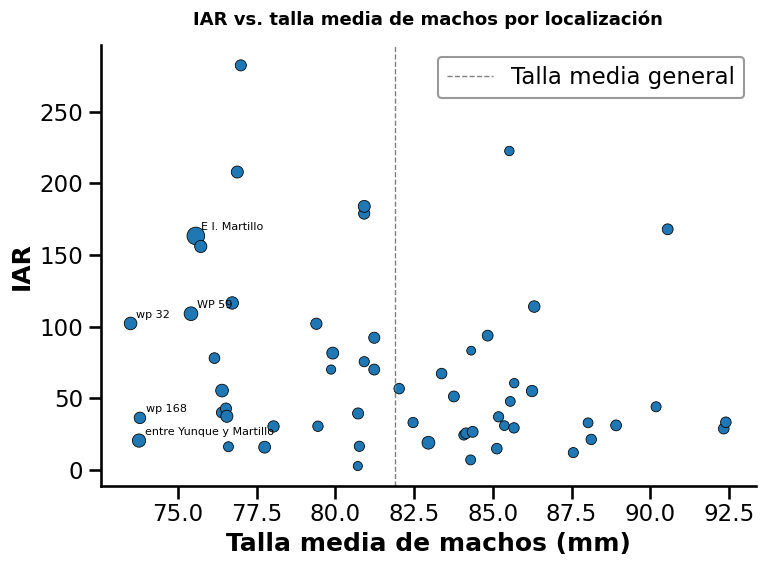

In [48]:
# Talla media de machos por localización, unida al IAR de esa localización
talla_por_loc = df_machos.groupby('localizacion').agg(
    talla_media=('largo_caparazon', 'mean'),
    n_machos=('largo_caparazon', 'count')
)
talla_iar = talla_por_loc.join(iar_por_loc[['IAR_Total']], how='inner').sort_values('talla_media')

print("Localizaciones ordenadas por menor talla media de machos:")
print(talla_iar.round(3).to_string())

# Las 5 localizaciones de menor talla y su IAR, tomamos estos para ver ?
menor_talla = talla_iar.head(5)
print(f"\nIAR promedio en las 5 localizaciones de menor talla: {menor_talla['IAR_Total'].mean():.4f}")
print(f"IAR promedio general (todas las localizaciones): {talla_iar['IAR_Total'].mean():.4f}")

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(data=talla_iar, x='talla_media', y='IAR_Total', size='n_machos', legend=False, color='#1f77b4', edgecolor='black')
for loc, row in menor_talla.iterrows():
    ax.annotate(loc, (row['talla_media'], row['IAR_Total']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.axvline(talla_iar['talla_media'].mean(), color='gray', linestyle='--', linewidth=1, label='Talla media general')
ax.set_xlabel('Talla media de machos (mm)', fontweight='bold')
ax.set_ylabel('IAR', fontweight='bold')
ax.set_title('IAR vs. talla media de machos por localización', fontsize=13, fontweight='bold', pad=15)
ax.legend(frameon=True, facecolor='white', edgecolor='gray')
sns.despine()
plt.tight_layout()
plt.show()

In [50]:
correlacion_talla_iar = talla_iar[['talla_media','IAR_Total']].corr().iloc[0,1]
print(f"Correlación entre talla media de machos e IAR: {correlacion_talla_iar:.3f}")  ## visualmente no se ve mucho y el indice no me da correlacion al parecer

Correlación entre talla media de machos e IAR: -0.219


In [51]:
mediana_iar_local = talla_iar['IAR_Total'].median()
talla_media_general = talla_iar['talla_media'].mean()

def clasificar(row):
    alto_iar = row['IAR_Total'] >= mediana_iar_local
    talla_chica = row['talla_media'] < talla_media_general
    if alto_iar and talla_chica:
        return '⚠️ ALTO IAR + talla chica (evitar pesca)'
    elif alto_iar and not talla_chica:
        return '✅ ALTO IAR + talla grande (pesca sostenible)'
    elif not alto_iar and talla_chica:
        return 'Bajo IAR + talla chica'
    else:
        return 'Bajo IAR + talla grande'

talla_iar['clasificacion'] = talla_iar.apply(clasificar, axis=1)

print(talla_iar[['talla_media','IAR_Total','n_machos','clasificacion']].sort_values('IAR_Total', ascending=False).to_string())

print("\nResumen por cuadrante:")
print(talla_iar['clasificacion'].value_counts())

                                                  talla_media   IAR_Total  n_machos                                 clasificacion
localizacion                                                                                                                     
wp 33                                               76.992553  282.500000        94      ⚠️ ALTO IAR + talla chica (evitar pesca)
wp 154                                              85.523333  222.666667        30  ✅ ALTO IAR + talla grande (pesca sostenible)
wp 157                                              76.881343  208.000000       134      ⚠️ ALTO IAR + talla chica (evitar pesca)
wp 159                                              80.914179  184.000000       134      ⚠️ ALTO IAR + talla chica (evitar pesca)
traves Snipe - P.Indios                             80.912000  179.000000       100      ⚠️ ALTO IAR + talla chica (evitar pesca)
wp 238                                              90.553571  168.000000        84  ✅ ALT

In [52]:
zonas_riesgo = talla_iar[talla_iar['clasificacion'].str.contains('evitar')]
print("Localizaciones a evitar (alto IAR + talla de machos por debajo del promedio):")
print(zonas_riesgo[['talla_media','IAR_Total','n_machos']].sort_values('IAR_Total', ascending=False).to_string())

Localizaciones a evitar (alto IAR + talla de machos por debajo del promedio):
                               talla_media   IAR_Total  n_machos
localizacion                                                    
wp 33                            76.992553  282.500000        94
wp 157                           76.881343  208.000000       134
wp 159                           80.914179  184.000000       134
traves Snipe - P.Indios          80.912000  179.000000       100
E I. Martillo                    75.563839  163.333333       448
wp 244                           75.720567  156.000000       141
wp 66                            76.720915  116.541353       153
WP 59                            75.410233  109.000000       215
wp 32                            73.490062  102.222222       161
wp 245                           79.393069  102.000000       101
wp 166                           81.232292   92.222222        96
cerca de Haskesheska             79.913281   81.500000       128
 frente bal.

C:\Users\fer22\AppData\Local\Temp\ipykernel_456\4045534127.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fer22\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


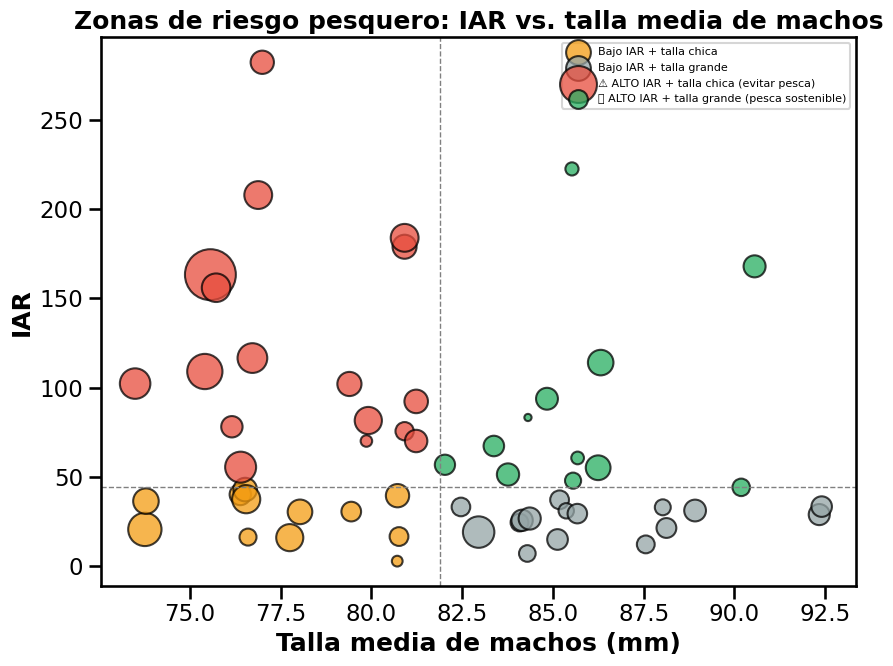

In [53]:
plt.close('all')
fig, ax = plt.subplots(figsize=(9,7))

colores = {
    '⚠️ ALTO IAR + talla chica (evitar pesca)': '#E74C3C',
    '✅ ALTO IAR + talla grande (pesca sostenible)': '#27AE60',
    'Bajo IAR + talla chica': '#F39C12',
    'Bajo IAR + talla grande': '#95A5A6'
}

for clase, grupo in talla_iar.groupby('clasificacion'):
    ax.scatter(grupo['talla_media'], grupo['IAR_Total'], s=grupo['n_machos']*3,
               color=colores[clase], edgecolor='black', alpha=0.75, label=clase)

ax.axvline(talla_media_general, color='gray', linestyle='--', linewidth=1)
ax.axhline(mediana_iar_local, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Talla media de machos (mm)', fontweight='bold')
ax.set_ylabel('IAR', fontweight='bold')
ax.set_title('Zonas de riesgo pesquero: IAR vs. talla media de machos', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

Al analizar la relación entre el índice de abundancia relativa (IAR) y la talla media de los machos por localización, no se observa una tendencia lineal general entre ambas variables : existen localizaciones de alto IAR tanto con talla de machos por encima como por debajo del promedio general. Esto indica que la abundancia relativa por sí sola no permite anticipar si una zona concentra machos de mayor o menor talla.

Sin embargo, al clasificar las localizaciones según ambas dimensiones de forma conjunta, se identifican zonas que combinan alto IAR con talla media de machos por debajo del promedio general , las cuales constituyen los casos de mayor riesgo pesquero: alta cantidad de individuos capturables, pero de tamaño reducido, lo que sugiere una posible sobreexplotación de machos jóvenes o una zona de reclutamiento que debería protegerse. En contraste, localizaciones combinan alto IAR con talla superior al promedio , representando las áreas más adecuadas para sostener la actividad pesquera sin comprometer la estructura de tallas de la población.

In [ ]:
from scipy import stats

r, p_valor = stats.pearsonr(talla_iar['talla_media'], talla_iar['IAR_Total'])

print(f"Correlación (r): {r:.3f}")
print(f"p-valor: {p_valor:.4f}")
print(f"n (cantidad de localizaciones): {len(talla_iar)}")

if p_valor < 0.05:
    print(f"\n→ La correlación ES estadísticamente significativa (p<0.05)")
else:
    print(f"\n→ La correlación NO es estadísticamente significativa (p≥0.05)")
    print(f"  Con este tamaño de muestra, no se puede descartar que la relación observada se deba al azar")
    

In [ ]:
resumen_sexo = df_segmented.groupby('sexo')['largo_caparazon'].agg(
    talla_media='mean', talla_mediana='median', n='count'
).round(2)
print("Talla por sexo (dataset extendido):")
print(resumen_sexo)

In [ ]:
talla_general_por_loc = df_segmented.groupby('localizacion').agg(
    talla_media=('largo_caparazon', 'mean'),
    n_individuos=('largo_caparazon', 'count')
)
talla_general_iar = talla_general_por_loc.join(iar_por_loc[['IAR_Total']], how='inner')

r_general, p_general = stats.pearsonr(talla_general_iar['talla_media'], talla_general_iar['IAR_Total'])
print(f"Correlación GENERAL (machos+hembras, dataset extendido): r={r_general:.3f}, p={p_general:.4f}, n={len(talla_general_iar)}")

In [ ]:
df_hembras = df_segmented[df_segmented['sexo'] == 2].copy()  # ajustar código real

talla_hembras_por_loc = df_hembras.groupby('localizacion').agg(
    talla_media=('largo_caparazon', 'mean'),
    n_hembras=('largo_caparazon', 'count')
)
talla_hembras_iar = talla_hembras_por_loc.join(iar_por_loc[['IAR_Total']], how='inner')

r_hembras, p_hembras = stats.pearsonr(talla_hembras_iar['talla_media'], talla_hembras_iar['IAR_Total'])
print(f"Correlación SOLO HEMBRAS: r={r_hembras:.3f}, p={p_hembras:.4f}, n={len(talla_hembras_iar)}")

In [ ]:
r_machos, p_machos = stats.pearsonr(talla_iar['talla_media'], talla_iar['IAR_Total'])
print(f"Correlación SOLO MACHOS: r={r_machos:.3f}, p={p_machos:.4f}, n={len(talla_iar)}")

"Con la incorporación de los nuevos registros de julio de 1997, se reevaluó la relación entre el índice de abundancia relativa (IAR) y la talla de caparazón, tanto a nivel general como diferenciando por sexo. A diferencia de lo observado con el conjunto de datos original —donde se había encontrado una correlación negativa significativa entre IAR y talla (r=-0.331, p=0.018)—, con el dataset ampliado esta relación deja de ser estadísticamente significativa tanto en el análisis general (r=-0.108, p=0.422) como al considerar exclusivamente hembras (r=-0.015, p=0.911) o machos (r=-0.219, p=0.101).

Si bien se confirma la existencia de un marcado dimorfismo sexual de tamaño en la especie analizada (talla media de machos: 80.4 mm; hembras: 70.5 mm), este no parece ser la causa de la correlación observada originalmente entre abundancia y tamaño, ya que la relación se debilitó de forma similar en ambos sexos al ampliar la muestra. Esto sugiere que el patrón de 'zonas de crecimiento' identificado inicialmente era más frágil de lo que aparentaba, y que con una muestra más amplia y representativa, no puede sostenerse una asociación robusta entre la abundancia relativa de una zona y el tamaño de los individuos que allí se encuentran."

In [ ]:
import plotly.express as px

# Coordenadas promedio por localización (igual que antes)
coords_por_loc = df_segmented.dropna(subset=['latitud', 'longitud']).groupby('localizacion').agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean')
).reset_index()

# Unir con talla_iar (que ya tiene la columna 'clasificacion')
mapa_clasificacion = coords_por_loc.merge(
    talla_iar.reset_index(),
    on='localizacion',
    how='inner'
)

print(f"Localizaciones con coordenadas y clasificación: {len(mapa_clasificacion)}")
print(mapa_clasificacion['clasificacion'].value_counts())

In [ ]:
fig_mapa_clasif = px.scatter_map(
    mapa_clasificacion,
    lat="latitud",
    lon="longitud",
    color="clasificacion",
    color_discrete_map=colores_categoria,
    size="IAR_Total",
    hover_name="localizacion",
    hover_data={"talla_media": ':.1f', "IAR_Total": ':.1f', "n_machos": True},  # ← corregido
    zoom=8,
    map_style="open-street-map",
    title="Zonas de riesgo pesquero: clasificación por IAR y talla de machos"
)

fig_mapa_clasif.update_layout(
    mapbox_bounds={
        "west": mapa_clasificacion.longitud.min(),
        "east": mapa_clasificacion.longitud.max(),
        "south": mapa_clasificacion.latitud.min(),
        "north": mapa_clasificacion.latitud.max()
    },
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor="rgba(255,255,255,0.8)")
)

fig_mapa_clasif.show()

## Ahora vamos a desagregar por temporada 

In [ ]:
iar_data_especie = []
for (loc, fecha, tipo), group in df_segmented.groupby(['localizacion', 'fecha', 'tipo']):
    num_capturas = len(group)
    num_trampas_evento = group['num_trampas'].iloc[0]
    iar = num_capturas / num_trampas_evento if num_trampas_evento > 0 else 0
    iar_data_especie.append({
        'Localización': loc, 'Fecha': fecha, 'Tipo': tipo,
        'N_Capturas': num_capturas, 'N_Trampas': num_trampas_evento, 'IAR': iar
    })

df_iar_especie = pd.DataFrame(iar_data_especie)

print(f"Eventos calculados: {len(df_iar_especie)}")
print(df_iar_especie.head())

In [ ]:
# Talla media de machos por localización y temporada
talla_temporal = df_machos.groupby(['localizacion', 'fecha']).agg(
    talla_media=('largo_caparazon', 'mean'),
    n_machos=('largo_caparazon', 'count')
).reset_index()

# IAR por localización y temporada
iar_temporal_completo = df_iar_especie.groupby(['Localización', 'Fecha']).agg(
    N_Capturas=('N_Capturas','sum'), N_Trampas=('N_Trampas','sum')
).reset_index()
iar_temporal_completo['IAR'] = iar_temporal_completo['N_Capturas'] / iar_temporal_completo['N_Trampas']

# Unir ambas, en una variable NUEVA (no reescribimos el nombre anterior por las dudas)
talla_iar_temp2 = talla_temporal.merge(
    iar_temporal_completo,
    left_on=['localizacion','fecha'], right_on=['Localización','Fecha'],
    how='inner'
)

print(f"Columnas: {talla_iar_temp2.columns.tolist()}")
print(talla_iar_temp2.head())

In [ ]:
talla_iar_temp2['mediana_iar_temp'] = talla_iar_temp2.groupby('fecha')['IAR'].transform('median')
talla_iar_temp2['talla_media_temp'] = talla_iar_temp2.groupby('fecha')['talla_media'].transform('mean')

def clasif(row):
    alto_iar = row['IAR'] >= row['mediana_iar_temp']
    talla_chica = row['talla_media'] < row['talla_media_temp']
    if alto_iar and talla_chica:
        return '⚠️ Alto IAR + talla chica'
    elif alto_iar and not talla_chica:
        return '✅ Alto IAR + talla grande'
    elif not alto_iar and talla_chica:
        return 'Bajo IAR + talla chica'
    else:
        return 'Bajo IAR + talla grande'

talla_iar_temp2['clasificacion'] = talla_iar_temp2.apply(clasif, axis=1)

print(talla_iar_temp2[['localizacion','fecha','talla_media','IAR','clasificacion']].to_string(index=False))

In [ ]:
coords_por_loc = df_segmented.dropna(subset=['latitud','longitud']).groupby('localizacion').agg(
    latitud=('latitud','mean'), longitud=('longitud','mean')
).reset_index()

mapa_temporal = talla_iar_temp2.merge(coords_por_loc, on='localizacion', how='inner')

# Ordenar las categorías de fecha cronológicamente para que el slider tenga sentido
orden_fechas = ['ene_96','abril_96','jul_96','oct_96','jul_97','oct_97','oct_98']
mapa_temporal['fecha'] = pd.Categorical(mapa_temporal['fecha'], categories=orden_fechas, ordered=True)
mapa_temporal = mapa_temporal.sort_values('fecha')

categorias_completas = ['⚠️ Alto IAR + talla chica', '✅ Alto IAR + talla grande', 
                          'Bajo IAR + talla chica', 'Bajo IAR + talla grande']

fig_animado = px.scatter_map(
    mapa_temporal,
    lat="latitud", lon="longitud",
    color="clasificacion",
    color_discrete_map=colores_categoria,
    category_orders={"clasificacion": categorias_completas},  # fuerza que todas las categorías existan desde el inicio
    size="IAR",
    hover_name="localizacion",
    hover_data={"talla_media": ':.1f', "IAR": ':.1f', "n_machos": True},
    animation_frame="fecha",
    zoom=8,
    map_style="open-street-map",
    title="Evolución de zonas de riesgo pesquero por temporada"
)

fig_animado.update_layout(
    mapbox_bounds={
        "west": mapa_temporal.longitud.min(), "east": mapa_temporal.longitud.max(),
        "south": mapa_temporal.latitud.min(), "north": mapa_temporal.latitud.max()
    }
)
fig_animado.show()

In [ ]:
print(pd.crosstab(mapa_temporal['fecha'], mapa_temporal['clasificacion']))

In [ ]:
print("Cantidad de localizaciones muestreadas por temporada:")
print(mapa_temporal.groupby('fecha')['localizacion'].nunique())

In [ ]:
composicion_temporada = pd.crosstab(mapa_temporal['fecha'], mapa_temporal['clasificacion'], normalize='index') * 100
print(composicion_temporada.round(1))

plt.close('all')
fig, ax = plt.subplots(figsize=(10,6))
composicion_temporada.plot(kind='bar', stacked=True, ax=ax, 
                              color=[colores_categoria.get(c,'gray') for c in composicion_temporada.columns])
ax.set_ylabel('% de localizaciones')
ax.set_title('Composición de zonas por categoría de riesgo, por temporada')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"Más allá de no poder confirmar una tendencia temporal clara, es relevante notar que en todas las temporadas analizadas existe una proporción considerable de localizaciones (entre 9% y 57%) clasificadas como de alto riesgo ('alto IAR + talla chica'). Esto sugiere que, independientemente de la variabilidad interanual, siempre hay zonas puntuales que combinan alta capturabilidad con predominio de individuos pequeños, y que estas zonas específicas —identificables temporada a temporada— constituyen un objetivo más preciso para las medidas de manejo que una recomendación generalizada para todo el canal Beagle o para todas las temporadas por igual."